# Titanic Data Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_theme(style="whitegrid")


## Question 1: Load and Inspect Dataset

In [3]:
# 1. Load the file titanic_data.csv using Pandas.
df = pd.read_csv('titanic_data.csv')

# 2. Display:
# o Number of rows and columns (.shape)
print("Shape of the dataset:", df.shape)
print("-" * 40)

# o Column names (.columns)
print("Columns:", df.columns.tolist())
print("-" * 40)

# o Data types (.dtypes)
print("Data types:\n", df.dtypes)
print("-" * 40)

# o First 10 rows (.head())
display(df.head(10))


Shape of the dataset: (891, 12)
----------------------------------------
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
----------------------------------------
Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
----------------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Question 2: Identify Missing Values

In [4]:
# 1. Display total missing values per column.
print("Total missing values per column:\n", df.isnull().sum())
print("-" * 40)

# 2. Check percentage of missing values for each column.
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values per column:\n", missing_percentage)


Total missing values per column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------------------------------------
Percentage of missing values per column:
 PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


## Question 3: Clean the Dataset

In [5]:
# 1. Fill missing Age values using the median age.
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# 2. Fill missing Embarked values with the most frequent value.
most_frequent_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_frequent_embarked)

# 3. Drop any rows that still contain large amounts of missing data (only if necessary).
# 'Cabin' has a lot of missing values (~77%), so we can drop the column.
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])

# Drop rows with any remaining missing values (e.g., in 'Embarked' or other columns)
df = df.dropna()

print("Missing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Question 4: Encode Categorical Features

In [6]:
# Convert the following columns into numeric form using Label Encoding / Mapping:
# Sex -> (male = 0, female = 1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked -> numeric categories
# Using factorization to assign numeric categories
df['Embarked'] = df['Embarked'].astype('category').cat.codes

display(df[['Sex', 'Embarked']].head())


,Sex,Embarked
0,0,2
1,1,0
2,1,2
3,1,2
4,0,2


## Question 5: Compute Summary Statistics

In [7]:
# 1. Display Mean, Median, Standard deviation, Minimum and Maximum values
numeric_df = df.select_dtypes(include=[np.number])
summary_stats = numeric_df.describe().T
summary_stats['median'] = numeric_df.median()
display(summary_stats[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'}))

print("-" * 40)

# 2. Compute survival counts:
survived_counts = df['Survived'].value_counts()
print(f"Survived (1): {survived_counts.get(1, 0)}")
print(f"Did not survive (0): {survived_counts.get(0, 0)}")


,mean,median,std,min,max
PassengerId,446.000000,446.0000,257.353842,1.00,891.0000
Survived,0.383838,0.0000,0.486592,0.00,1.0000
Pclass,2.308642,3.0000,0.836071,1.00,3.0000
Sex,0.352413,0.0000,0.477990,0.00,1.0000
Age,29.361582,28.0000,13.019697,0.42,80.0000
SibSp,0.523008,0.0000,1.102743,0.00,8.0000
Parch,0.381594,0.0000,0.806057,0.00,6.0000
Fare,32.204208,14.4542,49.693429,0.00,512.3292
Embarked,1.536476,2.0000,0.791503,0.00,2.0000


----------------------------------------
Survived (1): 342
Did not survive (0): 549


## Question 6: Grouped Survival Analysis

In [8]:
# Analyze survival patterns:
# 1. Survival by gender
print("Survival by gender:")
display(df.groupby('Sex')['Survived'].mean().to_frame())

# 2. Survival by passenger class(Pclass)
print("\nSurvival by passenger class (Pclass):")
display(df.groupby('Pclass')['Survived'].mean().to_frame())

# 3. Survival by embarkation port
print("\nSurvival by embarkation port:")
display(df.groupby('Embarked')['Survived'].mean().to_frame())


Survival by gender:


,Survived
Sex,
0,0.188908
1,0.742038



Survival by passenger class (Pclass):


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363



Survival by embarkation port:


,Survived
Embarked,
0,0.553571
1,0.389610
2,0.339009


## Question 7: Visualization – Survival Count

/tmp/ipykernel_12181/4230795928.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='Set2')


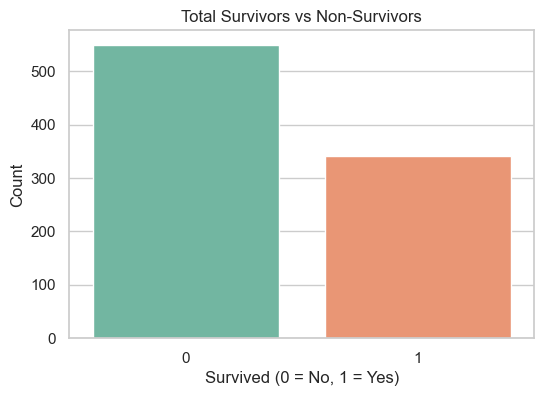

In [9]:
# Create a count plot showing total survivors vs non-survivors.
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Total Survivors vs Non-Survivors')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


## Question 8: Visualization – Survival by Gender

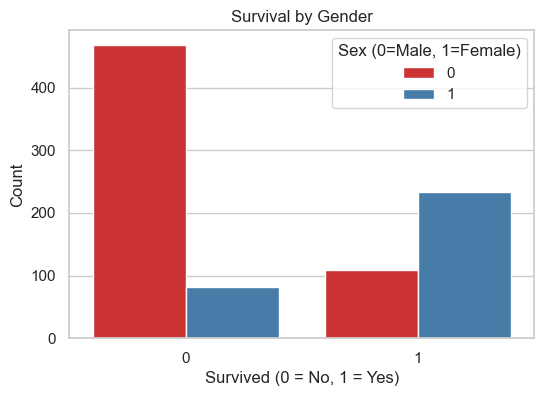

In [10]:
# Create a bar chart showing:
# Male survivors vs non-survivors
# Female survivors vs non-survivors
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', hue='Sex', data=df, palette='Set1')
plt.title('Survival by Gender')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Sex (0=Male, 1=Female)')
plt.show()


## Question 9: Visualization – Survival vs Passenger Class

/tmp/ipykernel_12181/3067381128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis', errorbar=None)


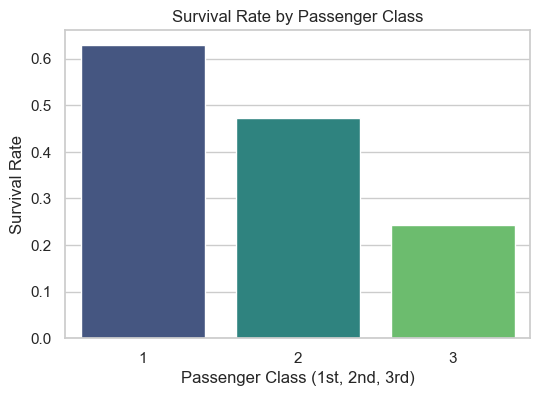

In [11]:
# Create a bar plot showing survival rates across different classes: 1st, 2nd, 3rd class
plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df, palette='viridis', errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1st, 2nd, 3rd)')
plt.ylabel('Survival Rate')
plt.show()


## Question 10: Histogram of Age

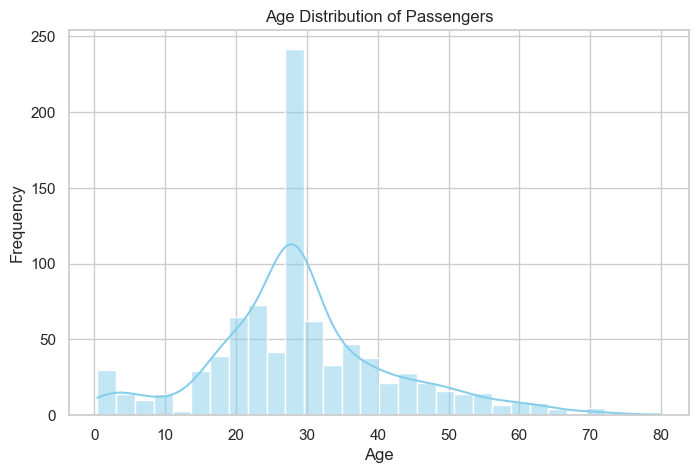

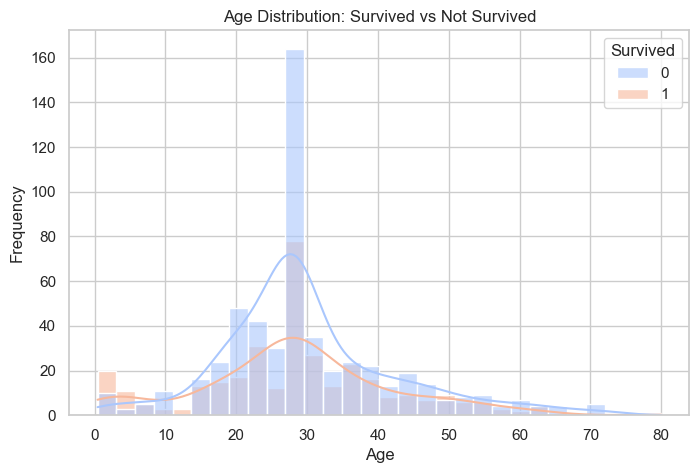

In [12]:
# Plot Age distribution of passengers
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Separate distributions for survived vs not survived (optional bonus)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, palette='coolwarm', alpha=0.6)
plt.title('Age Distribution: Survived vs Not Survived')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
